# Tema d'esame di Statistica e analisi dei dati

## Prova scritta del 22 giugno 2023 -- Prof. Malchiodi

Scrivete qui sotto i dati richiesti e riportateli anche su tutti i fogli protocollo che vi sono stati consegnati. Non potete tenere altri fogli bianchi rispetto a quelli che vi sono stati consegnati, né potete utilizzare calcolatrici portatili (avete a disposizione direttamente il computer!). Potete tenere sul banco, oltre alla penna, un libro e un quaderno di appunti per consultazione. Tutte le altre cose che avete con voi, __compresi telefoni e smartwatch__, devono essere appoggiate o appese lontano dai banchi, dove vi verrà indicato. Potete scegliere a quali domande rispondere scrivendo su carta e a quali scrivendo ed eseguendo codice, eventualmente arricchito da commenti o da celle di testo. A fine prova dovrete consegnare __tutti__ i fogli che vi sono stati dati, e inviare la versione digitale di questo notebook, contenente il vostro svolgimento, utilizzando il sito https://upload.di.unimi.it.

__Cognome e nome__

__Matricola__

## Esercizio 1 ##

In questo esercizio supporremo che la password per accedere a un sito di home banking sia composta da cinque
cifre decimali, e indicheremo con $p$ una prefissata password.

__1.__ Calcolate il numero di password distinte.


__2.__ Calcolate la probabilità che una password estratta uniformemente a
caso tra tutte quelle possibili sia uguale a $p$.



__3.__ Calcolate il numero di password distinte che contengono una
stessa cifra ripetuta nelle prime tre posizioni.



__4.__ Calcolate la probabilità del punto 1., condizionandola al fatto che
le cifre nelle prime tre posizioni in $p$ sono tutte uguali e scegliendo la password uniformemente a caso tra tutte quelle che hanno le prime tre cifre uguali.


__5.__ Calcolate il numero di password distinte che contengono una
stessa cifra ripetuta in tre posizioni consecutive.

__6.__ Calcolate la probabilità analoga a quella del punto 4, rimuovendo la richiesta che il blocco di tre cifre uguali si trovi all'inizio della password.

## Esercizio 2

Sia $X \sim \mathrm G(h)$ una variabile aleatoria distribuita secondo un modello geometrico di parametro $h$.

__1.__ Quali sono i valori $x$ per i quali ha senso calcolare la probabilità $\mathbb P(X > x)$?

__2.__ Per un generico $x \in \mathbb N$, calcolate la probabilità
$\mathbb P(X > x)$, esprimendola in funzione del parametro $h$.

__3.__ Esprimete in funzione di $x$ e $h$ il valore $F_X(x)$ restituito dalla funzione di ripartizione di $X$.

__4.__ Disegnate il grafico della fuzione $F_X$ ottenuta al punto precedente, fissando $h = \frac{4}{10}$.

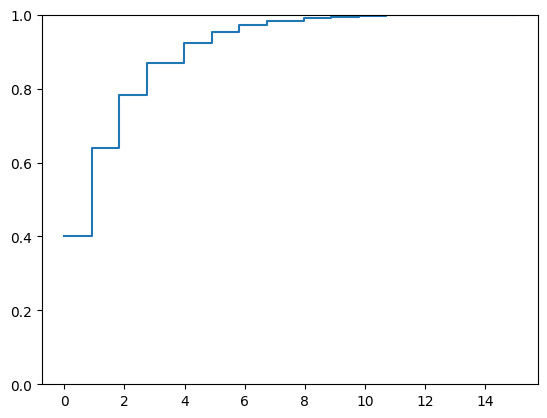

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def F(x, h):
    return 1 - ( 1 - h ) ** (np.floor(x) + 1)

x = np.linspace(0, 15)
y = F(x, 4/10)

plt.step(x, y)
plt.ylim(0, 1)
plt.show()


## Esercizio 3 ##

Per $n \in \mathbb N$ fissato, siano $X_1, \dots, X_n$ delle variabili aleatorie indipendenti e identicamente distribuite secondo un modello geometrico di parametro $h$. Nel resto dell'esercizio considereremo queste variabili come un campione estratto da una popolazione la cui distribuzione è la stessa della variabile aleatoria $X$ descritta nell'Esercizio 2 e supporremo $\mu = \mathbb E(X)$ e $T = \frac{1}{n} \sum_{i=1}^n X_i$.

__1.__ La variabile aleatoria $T$ è uno stimatore non distorto per $\mu$? Giustificate la vostra risposta.

__2.__ La variabile aleatoria $T$ descritta al punto precedente è uno stimatore non distorto per $h$? Giustificate la vostra risposta.

__3.__ Calcolate il bias e lo scarto quadrato dello stimatore $T$, __con riferimento alla stima del parametro $h$__.

__4.__ Lo stimatore $T$ gode della proprietà di consistenza in media quadratica
__relativamente alla stima del parametro $h$__? Giustificate la vostra risposta.

__5.__ Fissato $\epsilon > 0$, esprimete in funzione di $\epsilon$, $h$ e $n$ la probabilità dell'evento che si verifica quando l'errore (in valore assoluto) che si compie usando $T$ per stimare $\mu$ sia minore o uguale a $\epsilon$, giustificando i vostri passaggi e indicando eventuali approssimazioni che è necessario introdurre.

__6.__ Proponete uno stimatore $S$ per $h$, giustificando la scelta fatta.

## Esercizio 4 ##

Collegatevi al sito [upload.di.unimi.it](http://upload.di.unimi.it), selezionate l'esame di _Statistica e analisi dei dati_ per l'appello odierno e scaricate il file `banking.csv`. Questo file contiene le seguenti informazioni raccolte da un'ipotetica banca relativamente agli accessi al proprio sito di home banking:

- _utente_: codice univoco che identifica un utente;
- _tentativi_: numero di tentativi successivi di accedere al sito di home banking prima di riuscire ad autenticarsi;
- _minuti_: ora di accesso, indicata come numero di minuti passati dalla mezzanotte;
- _illecito_: valore binario che vale $1$ se l'accesso al sito di home banking è stato denunciato come illecito da parte del legittimo proprietario del conto, e $0$ altrimenti.

In questo file il carattere `,` separa le colonne.

__1.__ Scrivete ed eseguite del codice che vi permetta di capire quanti utenti distinti sono contenuti nel _dataset_, nonché quali siano gli attributi per i quali vi sono dei valori mancanti.

In [6]:
import pandas as pd

dati = pd.read_csv('banking.csv')
dati.head()

,utente,tentativi,minuti,illecito
0,342760,1.0,154,0
1,895078,1.0,154,0
2,36509,1.0,210,0
3,182008,1.0,973,1
4,961138,2.0,176,0


In [7]:
dati['utente'].nunique()

1752

In [12]:
for c in dati:
    print(f'colonna {c}, {sum(dati[c].isnull())} casi mancanti')

colonna utente, 0 casi mancanti
colonna tentativi, 7 casi mancanti
colonna minuti, 0 casi mancanti
colonna illecito, 0 casi mancanti


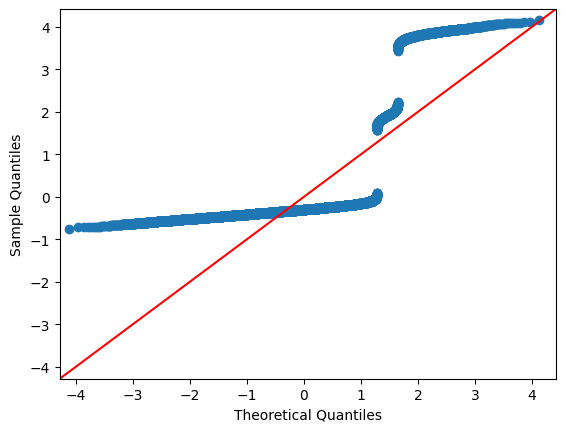

In [14]:
from statsmodels.api import qqplot

qqplot(dati['minuti'], fit=True, line='45')
plt.show()

__2.__ Valutate l'ipotesi che i valori dell'attributo _minuti_ possano essere assimilati a un campione estratto da una popolazione distribuita secondo un modello normale, spiegando il vostro ragionamento.

__3.__ Visualizzate graficamente l'attributo _minuti_, motivando il tipo di visualizzazione che avete scelto e commentate il risultato ottenuto anche alla luce di quanto emerso al punto precedente.

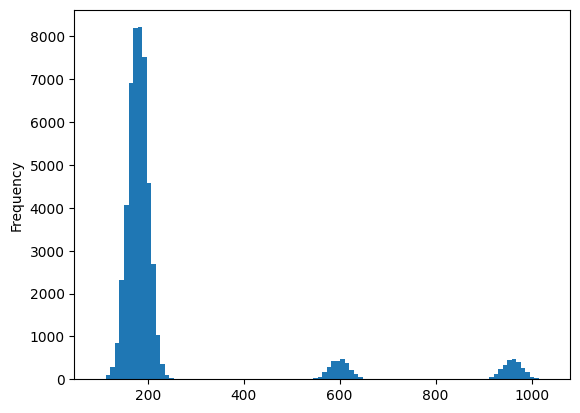

In [18]:
dati['minuti'].plot.hist(bins=100)
plt.show()

__4.__ Valutate l'ipotesi che vi sia una relazione tra gli attributi _minuti_ e _illecito_, specificando eventualmente di che tipo è la relazione determinata. Quali strumenti avete utilizzato per valutare questa ipotesi? Perché? 

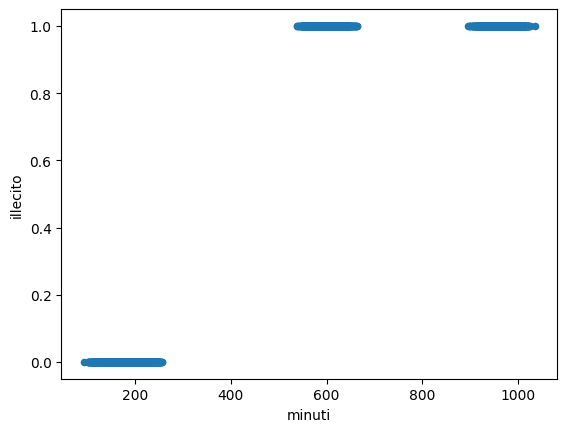

In [19]:
dati.plot.scatter('minuti', 'illecito')
plt.show()

In [21]:
print(dati['minuti'].corr(dati['illecito']))

0.9478451073104909


__5.__ Descrivete l'attributo _tentativi_ utilizzando la rappresentazione grafica che ritenete più adeguata, motivando la scelta fatta e commentando i risultati ottenuti.

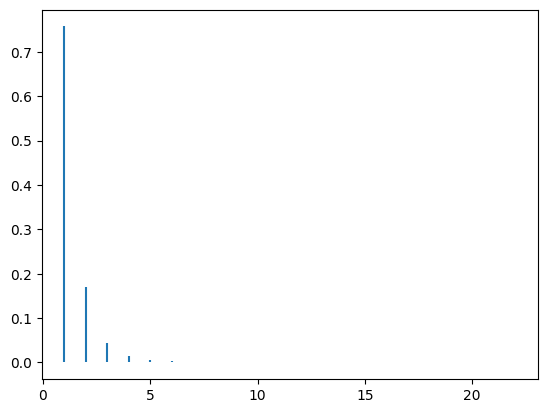

In [29]:
freq = dati['tentativi'].value_counts(normalize=True)
plt.vlines(freq.index, 0, freq.values)
 #plt.plot(freq.index, freq.values, 'o')
plt.show()

__6.__ I risultati ottenuti ai punti precedenti dovrebbero suggerire l'esistenza di due diverse tipologie di accessi al sito di home banking, discriminate dal valore dell'attributo _illecito_. Memorizzate in una variabile `dati_illeciti` tutti i casi del dataset che si riferiscono agli accessi di tipo illecito, e visualizzate graficamente la distribuzione dei corrispondenti valori dell'attributo _tentativi_.

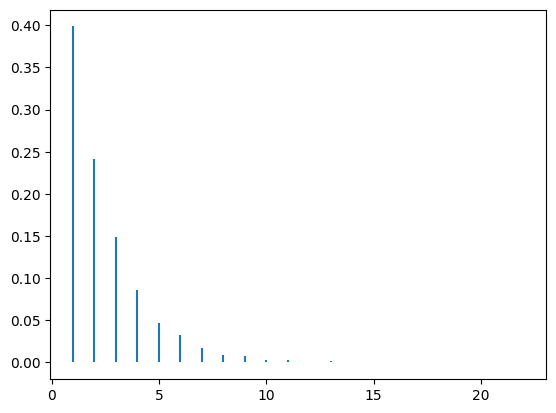

In [32]:
dati_illeciti = dati[dati['illecito'] == 1]

freq = dati_illeciti['tentativi'].value_counts(normalize=True)
plt.vlines(freq.index, 0, freq.values)
 #plt.plot(freq.index, freq.values, 'o')
plt.show()

__7.__ Sulla base dei risultati ottenuti nel punto precedente, considerate separatamente ognuno dei seguenti modelli di distribuzione, specificando se (e perché) si tratta di modelli ragionevoli per i valori memorizzati nella variabile `dati_illeciti`:

- il modello esponenziale,
- il modello gaussiano,
- il modello geometrico,
- il modello uniforme discreto.

## Esercizio 5 ##

In questo esercizio ci concentreremo sui valori dell'attributo _tentativi_ relativi __ai soli accessi illeciti__ al sito di home banking, e li interpreteremo come i valori assunti da un campione estratto da una popolazione distribuita come una variabile aleatoria $Y$.

__1.__ Ci sono valori mancanti per l'attributo in questione? Se sì, quanti sono?

In [36]:
num_na = (dati_illeciti['tentativi'].isnull().sum())
print(num_na)

7


__2.__ Stimate il valore atteso $\mathbb E(Y)$, specificando la dimensione del campione utilizzato e indicando eventuali proprietà dello stimatore utilizzato.

In [35]:
print(dati_illeciti['tentativi'].mean())

2.5055733988286417


In [37]:
print(len(dati_illeciti) - num_na)

5293


__3.__ I dati a disposizione permettono di garantire, con probabilità maggiore o uguale a 0.99, che la stima fatta al punto precedente comporti un errore (in valore assoluto) grande al più $\epsilon = 0.1$?

In [46]:
import scipy.stats as st

Z = st.norm()

In [48]:
Z.ppf(0.5)

np.float64(0.0)

In [50]:
epsilon = 0.1
sigma = dati_illeciti['tentativi'].std()

n_0 = (Z.ppf(1.99/2) * sigma / epsilon)**2
print(n_0)

2619.4909775321353


__4.__ Ipotizziamo che $Y \sim \mathrm G(h)$, e che $h$ sia sconosciuto. Proponete uno stimatore per $h$.

__5.__ Indicate se lo stimatore proposto al punto precedente gode di particolari proprietà, giustificando la vostra risposta.

__6.__ Applicate lo stimatore proposto al punto 4 per ottenere una stima $\hat h$ del parametro sconosciuto $h$. 

In [53]:
h_hat = 1 / (1 + dati_illeciti['tentativi'].mean())
print(h_hat)

0.2852600377256804


Nel resto dell'esercizio, calcolate le probabilità richieste facendo riferimento al modello assunto per $Y$ e sostituendo a $h$ la stima $\hat h$ ottenuta al punto precedente.

__7.__ Calcolate la probabilità $\mathbb P(3 < X < 8)$ che il numero di tentativi di autenticazione durante un accesso illecito sia strettamente compreso tra 3 e 8.

In [57]:
Y = st.geom(h_hat)

print(Y.cdf(7) - Y.cdf(3))

0.26983959225517173


__8.__ Un malintenzionato ha effettuato due tentativi di accesso andati a vuoto. Calcolate la probabilità che siano necessari più di due ulteriori tentativi di accesso.

In [59]:
1 - Y.cdf(1)

np.float64(0.7147399622743196)

In [ ]:
P(Y >= 2 + 2 | Y >= 2) = P(Y >= 2) = 1 - P(Y <= 1)